## Ejercicios de Probabilidad

In [1]:
from itertools import product
from fractions import Fraction

### Ejercicio 1: Diagrama de Venn

1.- En un salón de clases hay 60 alumnos. 30 de los alumnos estudian francés, 35 estudian ruso y 5 estudian francés y ruso. Dibuja un diagrama de Venn y calcula la probabilidad de que si se elige un estudiante al azar, este estudie solamente francés.

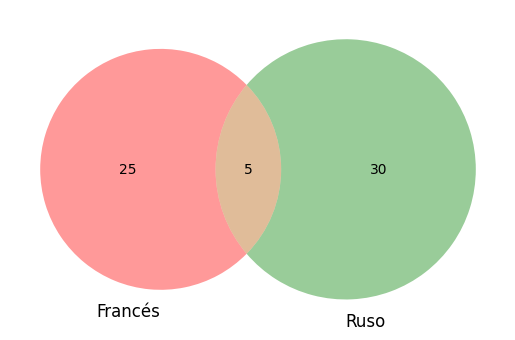

In [2]:
from matplotlib_venn import venn2
from matplotlib import pyplot as plt

venn2(subsets = (25, 30, 5), set_labels = ('Francés', 'Ruso'))
plt.show()

In [3]:
print("Probabilidad de estudiar solo francés:", Fraction(25, 60))
print("Como decimal:", float(Fraction(25, 60)))
print("Como porcentaje:", float(Fraction(25, 60))*100, "%")

Probabilidad de estudiar solo francés: 5/12
Como decimal: 0.4166666666666667
Como porcentaje: 41.66666666666667 %


### Ejercicio 2: Lanzamiento de 3 dados

2.- Se lanza un dado 3 veces.

- Describe al espacio muestral.
- Calcula la probabilidad de que salga la cara 1 en el primer lanzamiento.
- Calcula la probabilidad condicional del evento cae un número par en los tres lanzamientos dado que en el primer lanzamiento cae 2.
- Consideremos el evento: 'se obtiene sol en el segundo lanzamiento'. ¿Tal evento es independiente de los eventos anteriores?

In [4]:
Omega_dado3 = set(product([1,2,3,4,5,6], repeat = 3))
print("Espacio muestral:", len(Omega_dado3), "elementos")

def P(E, Omega):
    return Fraction(len(E & Omega), len(Omega))

Espacio muestral: 216 elementos


In [5]:
E_1 = {om for om in Omega_dado3 if om[0] == 1}
prob_E1 = P(E_1, Omega_dado3)
print("Probabilidad de que salga 1 en el primer lanzamiento:", prob_E1, "=", float(prob_E1))

Probabilidad de que salga 1 en el primer lanzamiento: 1/6 = 0.16666666666666666


In [6]:
E_2 = {om for om in Omega_dado3 if om[0] == 2}
Par = {om for om in E_2 if om[1] % 2 == 0 and om[2] % 2 == 0}
prob_cond = P(Par, E_2)
print("Probabilidad condicional:", prob_cond, "=", float(prob_cond))

Probabilidad condicional: 1/4 = 0.25


In [7]:
def indep(E, F, Omega):
    return P(E & F, Omega) == P(E, Omega) * P(F, Omega)

Omega_volado = set(product(["a","s"], repeat = 3))
S_2 = {om for om in Omega_volado if om[1] == "s"}
prob_S2 = P(S_2, Omega_volado)
print("Probabilidad de sol en el segundo lanzamiento:", prob_S2, "=", float(prob_S2))

es_independiente = indep(S_2, E_1, Omega_dado3)
print("¿Es independiente?", es_independiente)

Probabilidad de sol en el segundo lanzamiento: 1/2 = 0.5
¿Es independiente? True


### Ejercicio 3: Juego de dados

3.- Considera el experimento: Alicia y Karla lanzan 2 dados justos. Se tiene el siguiente juego:

- Si la suma de los dados es par, Alicia gana la cantidad máxima que sale en las caras y Karla pierde la cantidad mínima que sale en las caras.
- Si la suma de los dados es un número impar, Karla gana la cantidad de $5 y Alicia pierde la cantidad de $3.

¿Quién tiene más probabilidad de obtener mayor ganancia?

In [8]:
Omega_dado2 = set(product([1,2,3,4,5,6], repeat = 2))
Par = {om for om in Omega_dado2 if (om[0] + om[1]) % 2 == 0}

def Alicia(n):
    return {om for om in Omega_dado2 if (om[0] + om[1]) % 2 == 0 and max(om) == n}

def Karla(n):
    return {om for om in Omega_dado2 if (om[0] + om[1]) % 2 == 0 and min(om) == n}

In [9]:
G_A = sum([i * P(Alicia(i), Par) for i in range(1, 7)])
G_K = sum([i * P(Karla(i), Par) for i in range(1, 7)])
print("Ganancia esperada Alicia:", float(G_A))
print("Ganancia esperada Karla:", float(G_K))

Ganancia esperada Alicia: 4.388888888888889
Ganancia esperada Karla: 2.611111111111111


In [10]:
Impar = {om for om in Omega_dado2 if (om[0] + om[1]) % 2 == 1}
G_K_impar = 5 * P(Impar, Omega_dado2)
G_A_impar = 3 * P(Impar, Omega_dado2)

ganancia_total_A = G_A - G_A_impar
ganancia_total_K = G_K + G_K_impar

print("Ganancia total Alicia:", float(ganancia_total_A))
print("Ganancia total Karla:", float(ganancia_total_K))
print("Ganador:", "Karla" if ganancia_total_K > ganancia_total_A else "Alicia")

Ganancia total Alicia: 2.888888888888889
Ganancia total Karla: 5.111111111111111
Ganador: Karla


### Ejercicio 4: Distribución de la suma de 3 dados

4.- Escribe en un DataFrame la distribución asociada a la suma que se obtiene al lanzar 3 dados.

In [11]:
S = {om: om[0] + om[1] + om[2] for om in Omega_dado3}
from collections import defaultdict
dS = defaultdict(set)
for i, j in S.items():
    dS[j].add(i)

import pandas as pd
distS = {i: P(A, Omega_dado3) for i, A in dS.items()}
dist_S = pd.Series(distS).sort_index()
df_dist = pd.DataFrame({
    'Suma': dist_S.index,
    'Probabilidad': [str(p) for p in dist_S.values],
    'Decimal': [float(p) for p in dist_S.values]
})
print("Distribución de la suma de 3 dados:")
display(df_dist)

Distribución de la suma de 3 dados:


,Suma,Probabilidad,Decimal
0,3,1/216,0.004630
1,4,1/72,0.013889
2,5,1/36,0.027778
3,6,5/108,0.046296
4,7,5/72,0.069444
5,8,7/72,0.097222
6,9,25/216,0.115741
7,10,1/8,0.125000
8,11,1/8,0.125000
9,12,25/216,0.115741


In [12]:
print("\n" + "="*50)
print("RESUMEN DE RESULTADOS")
print("="*50)
print(f"1. Probabilidad de estudiar solo francés: {Fraction(25, 60)} = {float(Fraction(25, 60)):.2%}")
print(f"2a. Probabilidad de que salga 1 en el primer lanzamiento: {prob_E1} = {float(prob_E1):.2%}")
print(f"2b. Probabilidad condicional: {prob_cond} = {float(prob_cond):.2%}")
print(f"2c. Independencia: {es_independiente}")
print(f"3. Ganador: {'Karla' if ganancia_total_K > ganancia_total_A else 'Alicia'}")
print(f"   Alicia: ${float(ganancia_total_A):.2f}, Karla: ${float(ganancia_total_K):.2f}")


RESUMEN DE RESULTADOS
1. Probabilidad de estudiar solo francés: 5/12 = 41.67%
2a. Probabilidad de que salga 1 en el primer lanzamiento: 1/6 = 16.67%
2b. Probabilidad condicional: 1/4 = 25.00%
2c. Independencia: True
3. Ganador: Karla
   Alicia: $2.89, Karla: $5.11
